In [32]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
# Define the LeNet-5 architecture
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, kernel_size=2, stride=2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, kernel_size=2, stride=2)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

## ALEF

In [3]:
# Hyperparameters
learning_rate = 0.01
batch_size = 64
num_epochs = 50

In [16]:
# Data loading and transformations

# Load data from CSV files
train_data = pd.read_csv('mnist_train.csv')
test_data = pd.read_csv('mnist_test.csv')

# Extract features and labels
train_images = train_data.iloc[:, 1:].values.reshape(-1, 1, 28, 28) / 255.0  # Normalize to [0, 1]
train_labels = train_data.iloc[:, 0].values

test_images = test_data.iloc[:, 1:].values.reshape(-1, 1, 28, 28) / 255.0
test_labels = test_data.iloc[:, 0].values

# Convert to PyTorch tensors
train_images = torch.tensor(train_images, dtype=torch.float32)
train_labels = torch.tensor(train_labels, dtype=torch.long)

test_images = torch.tensor(test_images, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.long)

# Create datasets and dataloaders
train_dataset = torch.utils.data.TensorDataset(train_images, train_labels)
test_dataset = torch.utils.data.TensorDataset(test_images, test_labels)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)



In [17]:
# Model, loss function, and optimizer
model = LeNet5()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [19]:
# Training loop
train_loss = []
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_loss.append(epoch_loss / len(train_loader))
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {train_loss[-1]:.4f}")

Epoch [1/50], Loss: 2.1182
Epoch [2/50], Loss: 0.4217
Epoch [3/50], Loss: 0.2330
Epoch [4/50], Loss: 0.1684
Epoch [5/50], Loss: 0.1327
Epoch [6/50], Loss: 0.1124
Epoch [7/50], Loss: 0.0982
Epoch [8/50], Loss: 0.0871
Epoch [9/50], Loss: 0.0801
Epoch [10/50], Loss: 0.0723
Epoch [11/50], Loss: 0.0670
Epoch [12/50], Loss: 0.0624
Epoch [13/50], Loss: 0.0584
Epoch [14/50], Loss: 0.0542
Epoch [15/50], Loss: 0.0507
Epoch [16/50], Loss: 0.0483
Epoch [17/50], Loss: 0.0455
Epoch [18/50], Loss: 0.0432
Epoch [19/50], Loss: 0.0413
Epoch [20/50], Loss: 0.0394
Epoch [21/50], Loss: 0.0372
Epoch [22/50], Loss: 0.0358
Epoch [23/50], Loss: 0.0338
Epoch [24/50], Loss: 0.0323
Epoch [25/50], Loss: 0.0315
Epoch [26/50], Loss: 0.0296
Epoch [27/50], Loss: 0.0289
Epoch [28/50], Loss: 0.0273
Epoch [29/50], Loss: 0.0262
Epoch [30/50], Loss: 0.0249
Epoch [31/50], Loss: 0.0243
Epoch [32/50], Loss: 0.0232
Epoch [33/50], Loss: 0.0223
Epoch [34/50], Loss: 0.0216
Epoch [35/50], Loss: 0.0203
Epoch [36/50], Loss: 0.0197
E

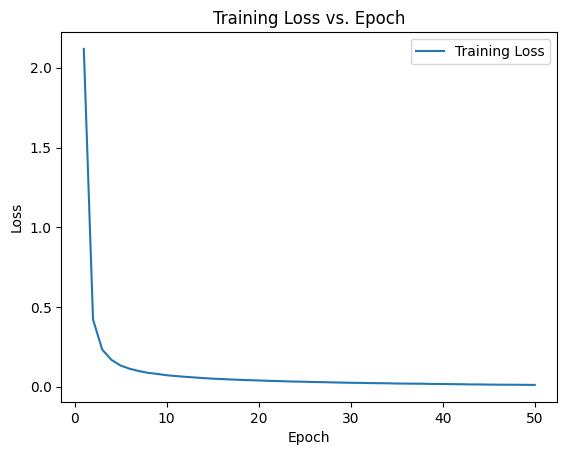

In [20]:
# Plotting the loss
plt.plot(range(1, num_epochs + 1), train_loss, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs. Epoch")
plt.legend()
plt.show()

In [21]:
# Testing the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Final Accuracy on Test Dataset: {accuracy:.2f}%")

Final Accuracy on Test Dataset: 98.84%


## BE

In [35]:
# Hyperparameters
initial_learning_rate = 0.01
batch_size = 64
num_epochs = 5
initial_temperature = 10
cooling_rate = 0.95

In [46]:
# Load data from CSV files
train_data = pd.read_csv('mnist_train.csv')
test_data = pd.read_csv('mnist_test.csv')

# Extract features and labels
train_images = train_data.iloc[:, 1:].values.reshape(-1, 1, 28, 28) / 255.0  # Normalize to [0, 1]
train_labels = train_data.iloc[:, 0].values

test_images = test_data.iloc[:, 1:].values.reshape(-1, 1, 28, 28) / 255.0
test_labels = test_data.iloc[:, 0].values

# Convert to PyTorch tensors
train_images = torch.tensor(train_images, dtype=torch.float32)
train_labels = torch.tensor(train_labels, dtype=torch.long)

test_images = torch.tensor(test_images, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.long)

# Split training data into training and validation sets
validation_size = int(0.1 * len(train_images))
train_size = len(train_images) - validation_size

# Split the images and labels
train_indices, val_indices = torch.utils.data.random_split(range(len(train_images)), [train_size, validation_size])
train_images_subset = train_images[train_indices.indices]
train_labels_subset = train_labels[train_indices.indices]
val_images_subset = train_images[val_indices.indices]
val_labels_subset = train_labels[val_indices.indices]

# Create datasets and dataloaders
train_dataset = torch.utils.data.TensorDataset(train_images_subset, train_labels_subset)
val_dataset = torch.utils.data.TensorDataset(val_images_subset, val_labels_subset)
test_dataset = torch.utils.data.TensorDataset(test_images, test_labels)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
# Update validation loader with subset
val_loader = torch.utils.data.DataLoader(dataset=torch.utils.data.TensorDataset(val_images_subset, val_labels_subset), batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [47]:
# Model, loss function
model = LeNet5()
criterion = nn.CrossEntropyLoss()

In [48]:
# Simulated Annealing for Optimized Learning Rate
def simulated_annealing(model, train_loader, val_loader, test_loader, criterion, initial_lr, initial_temp, cooling_rate, num_epochs):
    current_lr = initial_lr
    current_temp = initial_temp
    best_lr = current_lr
    best_accuracy = 0

    # Track accuracy for plotting
    val_accuracies = []
    test_accuracies = []
    temperatures = []
    learning_rates = []

    while current_temp > 1e-3:
        # Set optimizer with the current learning rate
        optimizer = optim.SGD(model.parameters(), lr=current_lr)

        # Train the model
        model.train()
        for epoch in range(num_epochs):
            for images, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # Evaluate on validation set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total

        # Evaluate on test set
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        # Store accuracy values for plotting
        val_accuracies.append(val_accuracy)
        test_accuracies.append(test_accuracy)
        temperatures.append(current_temp)
        learning_rates.append(current_lr)

        # Update the best learning rate if accuracy improves
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_lr = current_lr

        # Simulated annealing step
        delta = val_accuracy - best_accuracy
        if delta > 0 or np.exp(delta / current_temp) > random.random():
            if random.random() < 0.5:  # Only adjust half of the time
                current_lr += np.random.uniform(-0.001, 0.001)  # Small random adjustment
                current_lr = max(current_lr, 1e-6)  # Prevent extremely small learning rates

        current_temp *= cooling_rate

    return best_lr, best_accuracy, temperatures, learning_rates, val_accuracies, test_accuracies


In [ ]:
# Perform simulated annealing to find the best learning rate
best_lr, best_accuracy, temperatures, learning_rates, val_accuracies, test_accuracies = simulated_annealing(
    model, train_loader, val_loader, test_loader, criterion, initial_learning_rate, initial_temperature, cooling_rate, num_epochs
)

print(f"Optimized Learning Rate: {best_lr:.6f}, Best Validation Accuracy: {best_accuracy:.2f}%")

In [43]:
# Plotting validation and test accuracies vs. temperature
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

NameError: name 'temperatures' is not defined

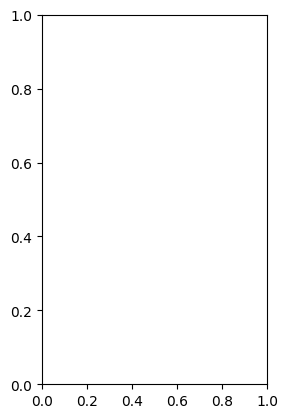

In [44]:
# Plot validation accuracy vs. temperature
plt.subplot(1, 2, 1)
plt.plot(temperatures, val_accuracies, label='Validation Accuracy', color='blue')
plt.xlabel('Temperature')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy vs. Temperature')
plt.legend()

In [ ]:
# Plot test accuracy vs. temperature
plt.subplot(1, 2, 2)
plt.plot(temperatures, test_accuracies, label='Test Accuracy', color='red')
plt.xlabel('Temperature')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy vs. Temperature')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Plotting validation and test accuracies vs. learning rate
plt.figure(figsize=(12, 6))

In [ ]:
# Plot validation accuracy vs. learning rate
plt.subplot(1, 2, 1)
plt.plot(learning_rates, val_accuracies, label='Validation Accuracy', color='blue')
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy vs. Learning Rate')
plt.legend()

In [ ]:
# Plot test accuracy vs. learning rate
plt.subplot(1, 2, 2)
plt.plot(learning_rates, test_accuracies, label='Test Accuracy', color='red')
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy vs. Learning Rate')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Final training with the optimized learning rate
optimizer = optim.SGD(model.parameters(), lr=best_lr)
train_loss = []
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_loss.append(epoch_loss / len(train_loader))
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {train_loss[-1]:.4f}")

In [ ]:
# Plotting the loss
plt.plot(range(1, num_epochs + 1), train_loss, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs. Epoch")
plt.legend()
plt.show()

In [ ]:
# Testing the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Final Accuracy on Test Dataset: {accuracy:.2f}%")